# NB2: Exploratory Data Analysis (EDA)

- Explore the movie dataset
- To understand patterns in genres, ratings, popularity and trends

## (1) Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

sns.set(style="whitegrid")

## (2) Load Dataset

In [3]:
movies_df = pd.read_csv("C:/Projects/07_Movie_Recommendation_System/data/movies_dataset.csv")
movies_df.head()

,id,title,overview,genres,release_date,vote_average,vote_count,popularity,original_language
0,1265609,War Machine,On one last grueling mission during Army Range...,"['Action', 'Science Fiction', 'Thriller']",2026-02-12,7.256,1080,374.3784,en
1,875828,Peaky Blinders: The Immortal Man,After his estranged son gets embroiled in a Na...,"['Crime', 'Drama']",2026-03-05,7.400,298,370.3607,en
2,687163,Project Hail Mary,Science teacher Ryland Grace wakes up on a spa...,"['Science Fiction', 'Adventure']",2026-03-15,8.251,309,323.2718,en
3,1290821,Shelter,A man living in self-imposed exile on a remote...,"['Action', 'Crime', 'Thriller']",2026-01-28,6.600,359,323.2197,en
4,83533,Avatar: Fire and Ash,In the wake of the devastating war against the...,"['Science Fiction', 'Adventure', 'Fantasy']",2025-12-17,7.265,1913,319.3325,en


## (3) Basic Inspection

In [4]:
print("Shape: ", movies_df.shape)

Shape:  (200, 9)


In [5]:
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 200 non-null    int64  
 1   title              200 non-null    object 
 2   overview           199 non-null    object 
 3   genres             200 non-null    object 
 4   release_date       198 non-null    object 
 5   vote_average       200 non-null    float64
 6   vote_count         200 non-null    int64  
 7   popularity         200 non-null    float64
 8   original_language  200 non-null    object 
dtypes: float64(2), int64(2), object(5)
memory usage: 14.2+ KB


In [6]:
movies_df.describe()

,id,vote_average,vote_count,popularity
count,2.000000e+02,200.000000,200.00000,200.000000
mean,7.836816e+05,5.965840,3657.72000,60.738073
std,5.350588e+05,2.268007,8377.81428,61.925396
min,1.200000e+02,0.000000,0.00000,18.059300
25%,2.426772e+05,5.700000,22.50000,29.457325
50%,8.653045e+05,6.549500,222.00000,40.417100
75%,1.247526e+06,7.323750,1835.00000,57.548900
max,1.650558e+06,8.717000,39176.00000,374.378400


## (4) Data cleaning

In [7]:
# Fix genres columns 
movies_df["genres"] = movies_df["genres"].apply(ast.literal_eval)

In [8]:
# Convert release_date to datetime
movies_df["release_date"] = pd.to_datetime(movies_df["release_date"],errors="coerce")
movies_df["year"] = movies_df["release_date"].dt.year

In [9]:
# Drop missing values
movies_df = movies_df.dropna(subset=["overview","genres"])
movies_df = movies_df.reset_index(drop=True)

## (5) Explode genres

In [10]:
movies_exploded = movies_df.explode("genres")
movies_exploded.head()

,id,title,overview,genres,release_date,vote_average,vote_count,popularity,original_language,year
0,1265609,War Machine,On one last grueling mission during Army Range...,Action,2026-02-12,7.256,1080,374.3784,en,2026.0
0,1265609,War Machine,On one last grueling mission during Army Range...,Science Fiction,2026-02-12,7.256,1080,374.3784,en,2026.0
0,1265609,War Machine,On one last grueling mission during Army Range...,Thriller,2026-02-12,7.256,1080,374.3784,en,2026.0
1,875828,Peaky Blinders: The Immortal Man,After his estranged son gets embroiled in a Na...,Crime,2026-03-05,7.400,298,370.3607,en,2026.0
1,875828,Peaky Blinders: The Immortal Man,After his estranged son gets embroiled in a Na...,Drama,2026-03-05,7.400,298,370.3607,en,2026.0


## (6) Top Genres

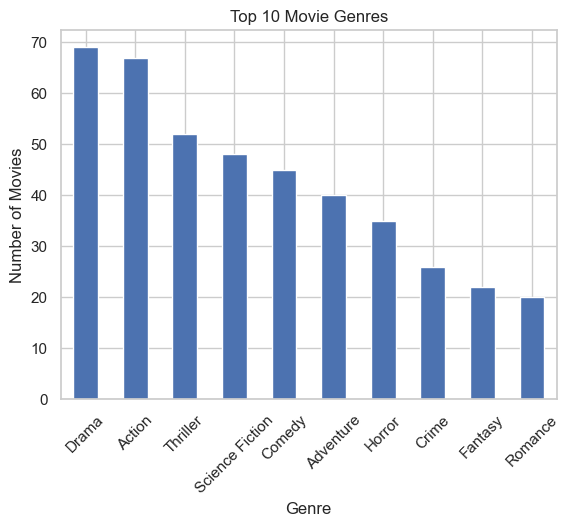

In [11]:
genre_counts = movies_exploded['genres'].value_counts().head(10)

plt.figure()
genre_counts.plot(kind="bar")
plt.title("Top 10 Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.show()

## (7) Rating Distribution

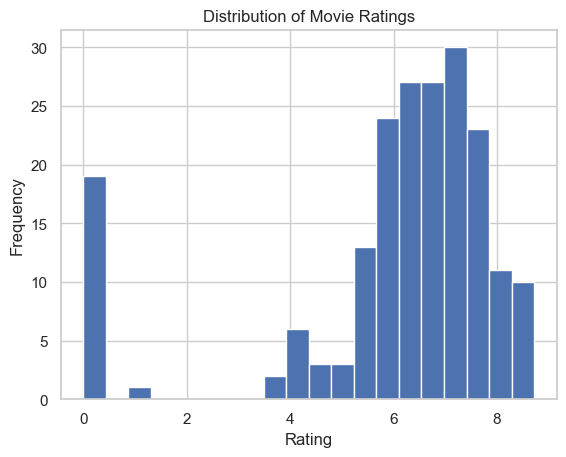

In [12]:
plt.figure()
plt.hist(movies_df["vote_average"],bins=20)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

## (8) Popularity Distribution

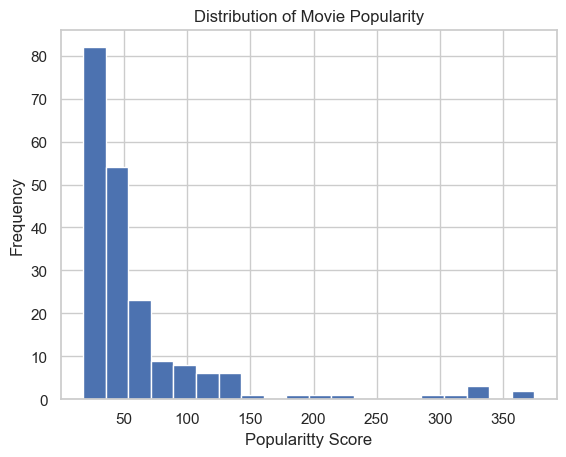

In [13]:
plt.figure()
plt.hist(movies_df["popularity"], bins=20)
plt.title("Distribution of Movie Popularity")
plt.xlabel("Popularitty Score")
plt.ylabel("Frequency")
plt.show()

## (9) Top Rated Movies

In [14]:
top_movies = movies_df.sort_values(by="vote_average", ascending=False).head(10)
top_movies[["title", "vote_average"]]

,title,vote_average
56,The Shawshank Redemption,8.717
109,The Godfather,8.687
174,Spirited Away,8.534
138,The Dark Knight,8.528
182,Parasite,8.493
186,Pulp Fiction,8.486
73,Interstellar,8.468
135,The Lord of the Rings: The Fellowship of the Ring,8.429
167,Inception,8.370
139,Chainsaw Man - The Movie: Reze Arc,8.329


## (10) Movies per Year

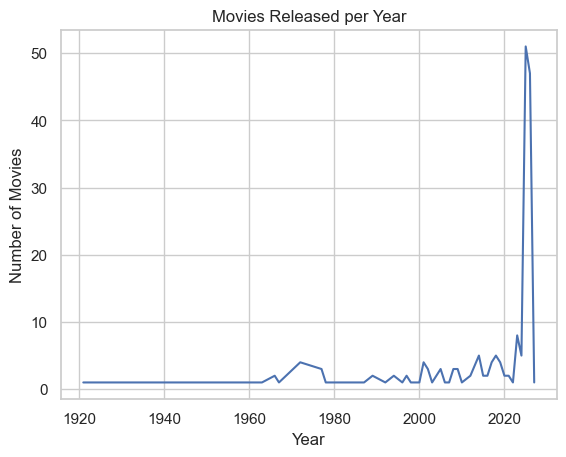

In [15]:
movies_per_year = movies_df["year"].value_counts().sort_index()

plt.figure()
movies_per_year.plot(kind="line")
plt.title("Movies Released per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()

## (11) Average Rating By Genre

<function matplotlib.pyplot.show(close=None, block=None)>

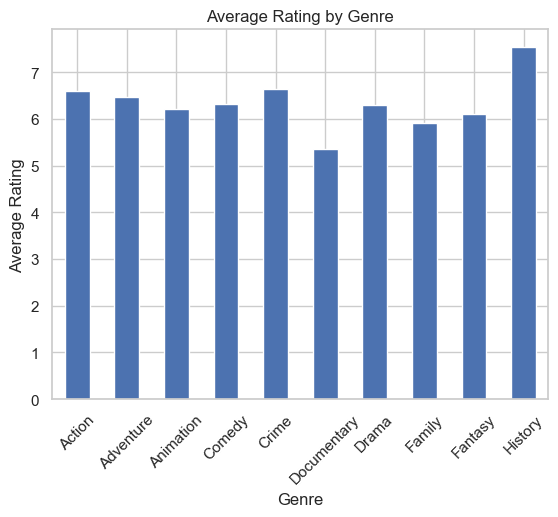

In [17]:
avg_rating_genre = movies_exploded.groupby("genres")["vote_average"].mean()
plt.figure()
avg_rating_genre.head(10).plot(kind="bar")
plt.title("Average Rating by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show

## (12) Language Distribution

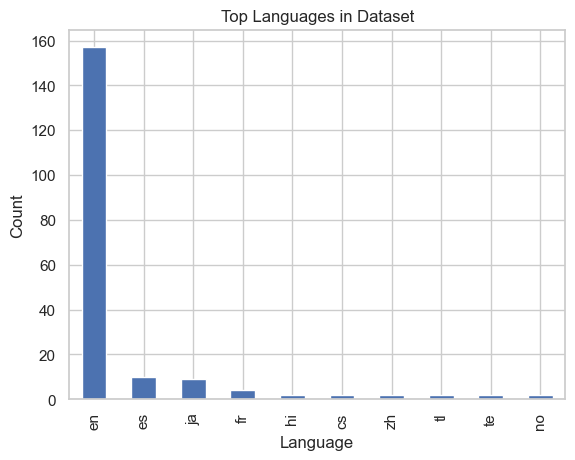

In [18]:
language_counts = movies_df["original_language"].value_counts().head(10)

plt.figure()
language_counts.plot(kind="bar")
plt.title("Top Languages in Dataset")
plt.xlabel("Language")
plt.ylabel("Count")
plt.show()